In [1]:
# Run this first — installs openpyxl if not already present (needed to read .xlsx)
!pip install openpyxl --quiet

---
## Step 1 — Upload Your Excel File
Run this cell — a **Choose Files** button will appear. Select your `.xlsx` file.  
The filename is captured automatically into `FILE_PATH` so nothing else needs changing.

In [2]:
from google.colab import files

print('Click the "Choose Files" button below and select your Excel file.')
uploaded = files.upload()   # opens a file picker

# Grab the filename automatically — works regardless of what you name the file
FILE_PATH = list(uploaded.keys())[0]
print(f'\nFile uploaded: {FILE_PATH}  ({len(uploaded[FILE_PATH])/1024:.1f} KB)')

Click the "Choose Files" button below and select your Excel file.


Saving Search (5).xlsx to Search (5).xlsx

File uploaded: Search (5).xlsx  (21.5 KB)


# EFFR Fixing Lag Analysis — 75th Percentile Trigger Study
### Instruments: SR3 / SR1 / ZQ | Market: SOFR · EFFR · Money Market

**Research question:** How many business days does it take for the EFFR fixing to change (≥1bp) after the 75th percentile first moves (≥0.5bp)?

---
| Parameter | Value |
|-----------|-------|
| Trigger threshold | 75th pct change ≥ 0.5bp (any tick) |
| EFFR change definition | ≥ 1bp in any direction |
| Lag unit | Business days (weekends excluded — dataset is business days only) |
| Weekend EFFR convention | Sat/Sun = Friday fixing (NY Fed rule) — irrelevant here as no weekend rows exist |

---

---
## Step 2 — Imports & Configuration
All tunable parameters live here. `FILE_PATH` is already set from the upload cell above.  
Change `P75_TRIGGER_BPS`, `EFFR_CHANGE_BPS`, or `MAX_LOOKFORWARD` here if needed.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# ── File & column mapping ────────────────────────────────────────────────────
# FILE_PATH is set automatically by the upload cell above
DATE_COL    = "Effective Date"
EFFR_COL    = "Rate (%)"
P75_COL     = "75th Percentile (%)"
DATE_FORMAT = "%m/%d/%Y"

# ── Analysis parameters ─────────────────────────────────────────────────────
P75_TRIGGER_BPS  = 0.5    # min 75th pct move to flag a trigger event
EFFR_CHANGE_BPS  = 1.0    # min EFFR move to count as "followed"
MAX_LOOKFORWARD  = 300    # business days before calling an event censored

# ── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
})

print("Config loaded.")

Config loaded.


---
## Step 3 — Load & Inspect the Data
Read the Excel, parse dates, sort **oldest → newest**, and do a quick sanity check.

In [4]:
df = pd.read_excel(FILE_PATH)

df["date"] = pd.to_datetime(df[DATE_COL], format=DATE_FORMAT)
df = df.sort_values("date").reset_index(drop=True)

effr  = df[EFFR_COL].values
p75   = df[P75_COL].values
dates = df["date"].values

print(f"Rows loaded      : {len(df)}")
print(f"Date range       : {df['date'].iloc[0].date()}  →  {df['date'].iloc[-1].date()}")
print(f"EFFR range       : {effr.min():.2f}%  –  {effr.max():.2f}%")
print(f"75th pct range   : {p75.min():.2f}%  –  {p75.max():.2f}%")
print()
df[["date", EFFR_COL, P75_COL]].head(10)

Rows loaded      : 289
Date range       : 2025-01-02  →  2026-02-27
EFFR range       : 3.64%  –  4.33%
75th pct range   : 3.64%  –  4.34%



/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,date,Rate (%),75th Percentile (%)
0,2025-01-02,4.33,4.34
1,2025-01-03,4.33,4.34
2,2025-01-06,4.33,4.34
3,2025-01-07,4.33,4.34
4,2025-01-08,4.33,4.34
5,2025-01-09,4.33,4.34
6,2025-01-10,4.33,4.34
7,2025-01-13,4.33,4.33
8,2025-01-14,4.33,4.33
9,2025-01-15,4.33,4.34


### 1b — Quick time-series plot: EFFR vs 75th percentile

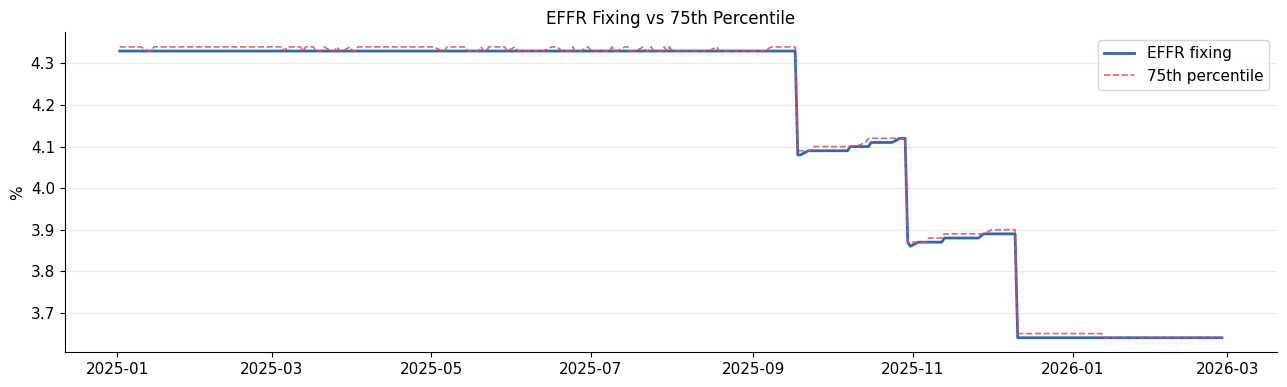

In [5]:
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(df["date"], effr, color="#3266ad", lw=2,   label="EFFR fixing")
ax.plot(df["date"], p75,  color="#E24B4A", lw=1.2, ls="--", label="75th percentile", alpha=0.85)

ax.set_title("EFFR Fixing vs 75th Percentile", fontsize=12)
ax.set_ylabel("%")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

---
## Step 2 — Identify Trigger Events

**Rule:** A trigger fires on day `i` when  
`|p75[i] − p75[i−1]| ≥ P75_TRIGGER_BPS / 100`

We record: trigger date, old/new p75 value, change in bps, direction, and the EFFR level on that day.

In [6]:
trigger_threshold = P75_TRIGGER_BPS / 100   # bps → decimal

triggers = []
for i in range(1, len(p75)):
    delta = p75[i] - p75[i - 1]
    if abs(delta) >= trigger_threshold:
        triggers.append({
            "idx"         : i,
            "date"        : pd.Timestamp(dates[i]),
            "p75_prev"    : round(p75[i - 1], 4),
            "p75_new"     : round(p75[i],     4),
            "p75_chg_bps" : round(delta * 100, 2),
            "direction"   : "Down" if delta < 0 else "Up",
            "effr"        : effr[i],
        })

trigger_df = pd.DataFrame(triggers)

print(f"Total triggers   : {len(trigger_df)}")
print(f"  Down moves     : {(trigger_df['direction']=='Down').sum()}")
print(f"  Up   moves     : {(trigger_df['direction']=='Up').sum()}")
print()
trigger_df[["date","p75_prev","p75_new","p75_chg_bps","direction","effr"]]

Total triggers   : 54
  Down moves     : 26
  Up   moves     : 28



,date,p75_prev,p75_new,p75_chg_bps,direction,effr
0,2025-01-13,4.34,4.33,-1.0,Down,4.33
1,2025-01-15,4.33,4.34,1.0,Up,4.33
2,2025-03-06,4.34,4.33,-1.0,Down,4.33
3,2025-03-07,4.33,4.34,1.0,Up,4.33
4,2025-03-13,4.34,4.33,-1.0,Down,4.33
5,2025-03-14,4.33,4.34,1.0,Up,4.33
6,2025-03-18,4.34,4.33,-1.0,Down,4.33
7,2025-03-21,4.33,4.34,1.0,Up,4.33
8,2025-03-24,4.34,4.33,-1.0,Down,4.33
9,2025-03-26,4.33,4.34,1.0,Up,4.33


### 2b — Visualise trigger events on the time series

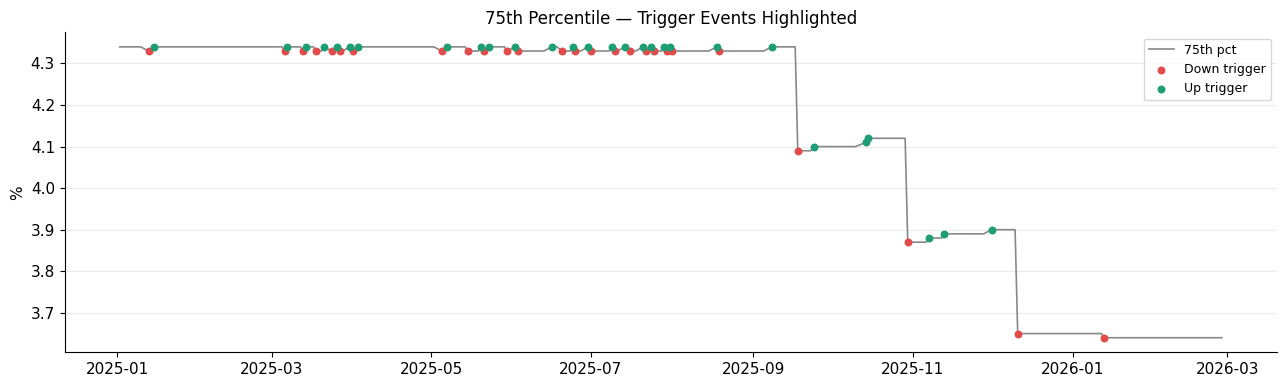

In [7]:
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(df["date"], p75, color="#888", lw=1.2, label="75th pct", zorder=2)

dn = trigger_df[trigger_df["direction"] == "Down"]
up = trigger_df[trigger_df["direction"] == "Up"]

ax.scatter(dn["date"], dn["p75_new"], color="#E24B4A", s=22, zorder=4, label="Down trigger")
ax.scatter(up["date"], up["p75_new"], color="#1D9E75", s=22, zorder=4, label="Up trigger")

ax.set_title("75th Percentile — Trigger Events Highlighted", fontsize=12)
ax.set_ylabel("%")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

---
## Step 3 — Measure Lag to EFFR Fixing Change

For each trigger day `i`, scan forward day by day:  
- **Found:** first `j > i` where `|effr[j] − effr[i]| ≥ EFFR_CHANGE_BPS / 100`  
- **Lag** = `j − i` (business days)  
- **Censored** = no qualifying move found within `MAX_LOOKFORWARD` days  

In [8]:
effr_threshold = EFFR_CHANGE_BPS / 100

lags, effr_moves, censored_flags = [], [], []

for row in triggers:
    i        = row["idx"]
    baseline = effr[i]
    lag, effr_move = None, None

    for j in range(i + 1, min(i + 1 + MAX_LOOKFORWARD, len(effr))):
        move = effr[j] - baseline
        if abs(move) >= effr_threshold:
            lag       = j - i
            effr_move = round(move * 100, 2)
            break

    lags.append(lag)
    effr_moves.append(effr_move)
    censored_flags.append(lag is None)

trigger_df["lag_bdays"]     = lags
trigger_df["effr_move_bps"] = effr_moves
trigger_df["censored"]      = censored_flags

# Direction concordance: did EFFR eventually move in the SAME direction as p75?
trigger_df["concordant"] = trigger_df.apply(
    lambda r: bool(r["p75_chg_bps"] * r["effr_move_bps"] > 0)
              if pd.notna(r["effr_move_bps"]) else None, axis=1
)

print(f"Events with EFFR change found : {trigger_df['lag_bdays'].notna().sum()}")
print(f"Censored (no change found)    : {trigger_df['censored'].sum()}")
print()
trigger_df[["date","p75_chg_bps","direction","effr","lag_bdays","effr_move_bps","concordant","censored"]]

Events with EFFR change found : 52
Censored (no change found)    : 2



,date,p75_chg_bps,direction,effr,lag_bdays,effr_move_bps,concordant,censored
0,2025-01-13,-1.0,Down,4.33,172.0,-25.0,True,False
1,2025-01-15,1.0,Up,4.33,170.0,-25.0,False,False
2,2025-03-06,-1.0,Down,4.33,136.0,-25.0,True,False
3,2025-03-07,1.0,Up,4.33,135.0,-25.0,False,False
4,2025-03-13,-1.0,Down,4.33,131.0,-25.0,True,False
5,2025-03-14,1.0,Up,4.33,130.0,-25.0,False,False
6,2025-03-18,-1.0,Down,4.33,128.0,-25.0,True,False
7,2025-03-21,1.0,Up,4.33,125.0,-25.0,False,False
8,2025-03-24,-1.0,Down,4.33,124.0,-25.0,True,False
9,2025-03-26,1.0,Up,4.33,122.0,-25.0,False,False


---
## Step 4 — Summary Statistics
Overall lag stats, then sliced by direction and move size.

In [9]:
valid    = trigger_df.dropna(subset=["lag_bdays"])
lags_arr = valid["lag_bdays"].values.astype(int)

# ── Overall ───────────────────────────────────────────────────────────────────
stats = pd.Series({
    "count"  : len(valid),
    "mean"   : round(lags_arr.mean(), 1),
    "median" : round(float(np.median(lags_arr)), 1),
    "std"    : round(lags_arr.std(), 1),
    "min"    : int(lags_arr.min()),
    "p10"    : int(np.percentile(lags_arr, 10)),
    "p25"    : int(np.percentile(lags_arr, 25)),
    "p75"    : int(np.percentile(lags_arr, 75)),
    "p90"    : int(np.percentile(lags_arr, 90)),
    "max"    : int(lags_arr.max()),
}, name="All triggers (bdays)")

print("=" * 45)
print(stats.to_string())
print()

# ── By direction ─────────────────────────────────────────────────────────────
dir_stats = valid.groupby("direction")["lag_bdays"].agg(
    count="count", mean="mean", median="median", std="std", min="min", max="max"
).round(1)
print("By direction:")
print(dir_stats)
print()

# ── By move magnitude ────────────────────────────────────────────────────────
valid = valid.copy()
valid["move_cat"] = np.where(valid["p75_chg_bps"].abs() >= 5, "Decisive (>=5bp)", "Small (<5bp)")
mag_stats = valid.groupby("move_cat")["lag_bdays"].agg(
    count="count", mean="mean", median="median", std="std", min="min", max="max"
).round(1)
print("By move magnitude:")
print(mag_stats)

count      52.0
mean       68.3
median     59.5
std        46.1
min         1.0
p10        10.0
p25        34.0
p75       116.0
p90       129.0
max       172.0

By direction:
           count  mean  median   std  min    max
direction                                       
Down          24  74.8    68.0  44.9  1.0  172.0
Up            28  62.7    53.0  47.9  1.0  170.0

By move magnitude:
                  count  mean  median   std  min    max
move_cat                                               
Decisive (>=5bp)      2   7.5     7.5   9.2  1.0   14.0
Small (<5bp)         50  70.7    61.0  45.7  1.0  172.0


---
## Step 5 — Conditional Probability Table

`P(EFFR changes within N business days)` — the core trading signal.  
Split into **all triggers**, **decisive moves (≥5bp)**, and **small moves (<5bp)**.

In [10]:
def cond_prob_table(lag_series, label=""):
    """Print P(change within N days) for a range of N."""
    arr = lag_series.dropna().values.astype(int)
    N   = len(arr)
    if N == 0:
        print(f"{label}: no data")
        return
    rows = []
    for n in [1, 2, 3, 5, 7, 8, 10, 13, 14, 15, 20, 22, 30, 50, 75, 100]:
        c = (arr <= n).sum()
        rows.append({"N (bdays)": n, "P(≤N)": f"{c/N:.1%}", "Count": f"{c}/{N}"})
    tbl = pd.DataFrame(rows).set_index("N (bdays)")
    print(f"\n{'─'*35}")
    print(f"  {label}  (n={N})")
    print(f"{'─'*35}")
    print(tbl.to_string())

cond_prob_table(valid["lag_bdays"],                                      "All triggers")
cond_prob_table(valid.loc[valid["p75_chg_bps"].abs() >= 5, "lag_bdays"], "Decisive moves ≥5bp")
cond_prob_table(valid.loc[valid["p75_chg_bps"].abs()  < 5, "lag_bdays"], "Small moves <5bp")


───────────────────────────────────
  All triggers  (n=52)
───────────────────────────────────
           P(≤N)  Count
N (bdays)              
1           3.8%   2/52
2           5.8%   3/52
3           5.8%   3/52
5           5.8%   3/52
7           5.8%   3/52
8           9.6%   5/52
10         11.5%   6/52
13         13.5%   7/52
14         15.4%   8/52
15         17.3%   9/52
20         17.3%   9/52
22         21.2%  11/52
30         21.2%  11/52
50         44.2%  23/52
75         59.6%  31/52
100        73.1%  38/52

───────────────────────────────────
  Decisive moves ≥5bp  (n=2)
───────────────────────────────────
            P(≤N) Count
N (bdays)              
1           50.0%   1/2
2           50.0%   1/2
3           50.0%   1/2
5           50.0%   1/2
7           50.0%   1/2
8           50.0%   1/2
10          50.0%   1/2
13          50.0%   1/2
14         100.0%   2/2
15         100.0%   2/2
20         100.0%   2/2
22         100.0%   2/2
30         100.0%   2/2
50        

---
## Step 6 — Conditional Probability Curve
Plot `P(EFFR changes within N days)` for N = 1…30, split by direction.

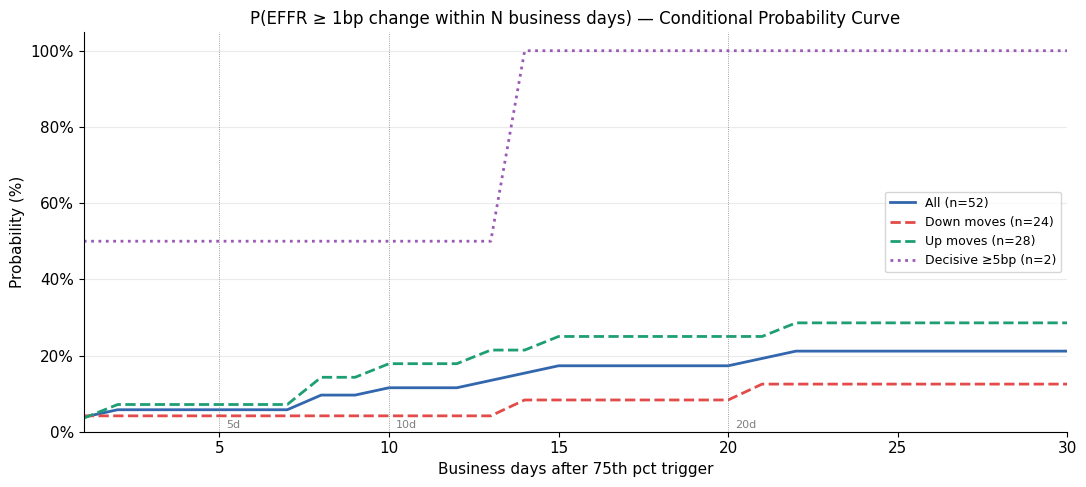

In [11]:
def cp_curve(lag_arr, label, color, ax, ls="-"):
    """Plot cumulative probability curve onto ax."""
    arr = lag_arr.dropna().values.astype(int)
    N   = len(arr)
    ns  = list(range(1, 31))
    ps  = [(arr <= n).sum() / N * 100 for n in ns]
    ax.plot(ns, ps, color=color, lw=2, ls=ls, label=f"{label} (n={N})")

fig, ax = plt.subplots(figsize=(11, 5))

cp_curve(valid["lag_bdays"],                                                "All",         "#3266ad", ax)
cp_curve(valid.loc[valid["direction"]=="Down", "lag_bdays"],               "Down moves",  "#E24B4A", ax, ls="--")
cp_curve(valid.loc[valid["direction"]=="Up",   "lag_bdays"],               "Up moves",    "#1D9E75", ax, ls="--")
cp_curve(valid.loc[valid["p75_chg_bps"].abs() >= 5, "lag_bdays"],          "Decisive ≥5bp","#9B59B6", ax, ls=":")

for ref_n in [5, 10, 20]:
    ax.axvline(ref_n, color="gray", lw=0.6, ls=":")
    ax.text(ref_n + 0.2, 1, f"{ref_n}d", fontsize=8, color="gray")

ax.set_xlabel("Business days after 75th pct trigger", fontsize=11)
ax.set_ylabel("Probability (%)", fontsize=11)
ax.set_title("P(EFFR ≥ 1bp change within N business days) — Conditional Probability Curve", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.set_xlim(1, 30)
ax.set_ylim(0, None)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig("cprob_curve.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Step 7 — Lag Distribution Histogram

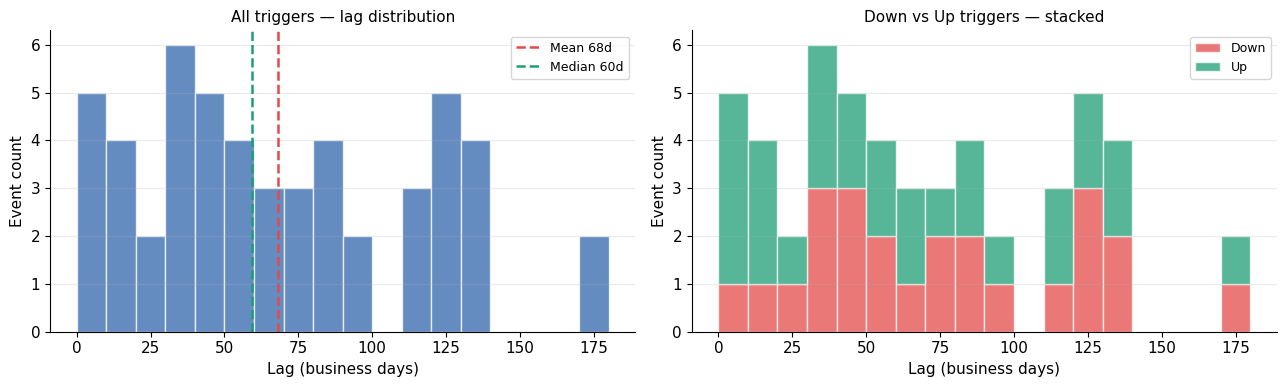

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── All triggers histogram ────────────────────────────────────────────────────
ax = axes[0]
ax.hist(lags_arr, bins=range(0, 181, 10),
        color="#3266ad", alpha=0.75, edgecolor="white", lw=0.5)
ax.axvline(lags_arr.mean(),            color="#E24B4A", lw=1.8, ls="--",
           label=f"Mean {lags_arr.mean():.0f}d")
ax.axvline(float(np.median(lags_arr)), color="#1D9E75", lw=1.8, ls="--",
           label=f"Median {np.median(lags_arr):.0f}d")
ax.set_xlabel("Lag (business days)", fontsize=11)
ax.set_ylabel("Event count", fontsize=11)
ax.set_title("All triggers — lag distribution", fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)

# ── Down vs Up stacked histogram ──────────────────────────────────────────────
ax = axes[1]
dn_lags = valid.loc[valid["direction"]=="Down", "lag_bdays"].values.astype(int)
up_lags = valid.loc[valid["direction"]=="Up",   "lag_bdays"].values.astype(int)
bins    = range(0, 181, 10)

ax.hist([dn_lags, up_lags], bins=bins, stacked=True,
        color=["#E24B4A", "#1D9E75"], alpha=0.75,
        edgecolor="white", lw=0.5, label=["Down", "Up"])
ax.set_xlabel("Lag (business days)", fontsize=11)
ax.set_ylabel("Event count", fontsize=11)
ax.set_title("Down vs Up triggers — stacked", fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("lag_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Step 8 — Lag Over Time (Scatter)
Reveals regime changes — e.g. H1 2025 "long wait" vs H2 2025 active cutting cycle.

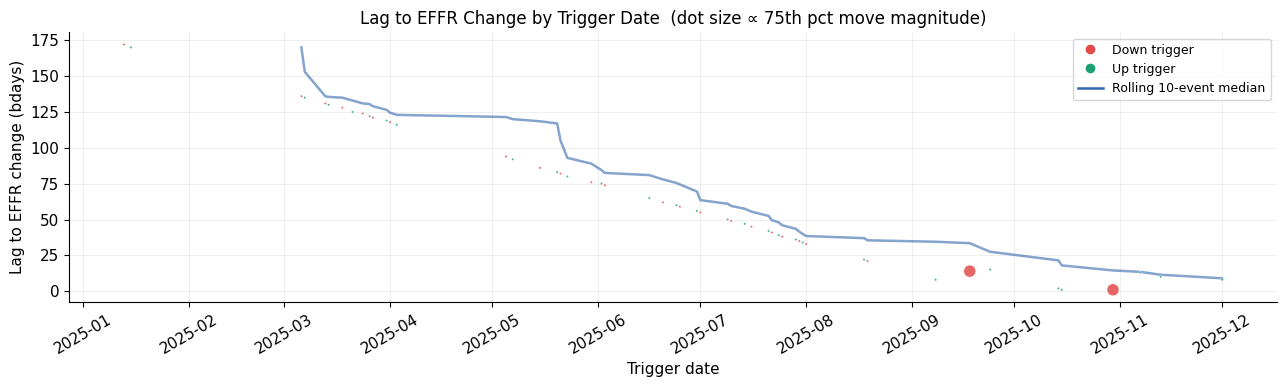

In [13]:
fig, ax = plt.subplots(figsize=(13, 4))

color_map  = {"Down": "#E24B4A", "Up": "#1D9E75"}
size_map   = valid["p75_chg_bps"].abs().clip(1, 30) * 3   # larger dot = bigger move
colors_vec = valid["direction"].map(color_map)

sc = ax.scatter(valid["date"], valid["lag_bdays"],
                c=colors_vec, s=size_map, alpha=0.85, zorder=4, edgecolors="white", lw=0.4)

# Rolling 10-event median trend
rolling_med = valid.set_index("date")["lag_bdays"].rolling(10, min_periods=3).median()
ax.plot(rolling_med.index, rolling_med.values,
        color="#3266ad", lw=1.8, ls="-", alpha=0.6, label="Rolling 10-event median")

ax.set_xlabel("Trigger date", fontsize=11)
ax.set_ylabel("Lag to EFFR change (bdays)", fontsize=11)
ax.set_title("Lag to EFFR Change by Trigger Date  (dot size ∝ 75th pct move magnitude)", fontsize=12)
ax.grid(alpha=0.2)
ax.tick_params(axis="x", rotation=30)

legend_els = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#E24B4A", markersize=8, label="Down trigger"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#1D9E75", markersize=8, label="Up trigger"),
    Line2D([0],[0], color="#3266ad", lw=1.8, ls="-", label="Rolling 10-event median"),
]
ax.legend(handles=legend_els, fontsize=9)

plt.tight_layout()
plt.savefig("lag_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Step 9 — Regime Analysis: Split Small vs Decisive Moves
Key trading insight: ±1bp 75th pct oscillations (noise) vs large decisive moves (Fed action) behave very differently.

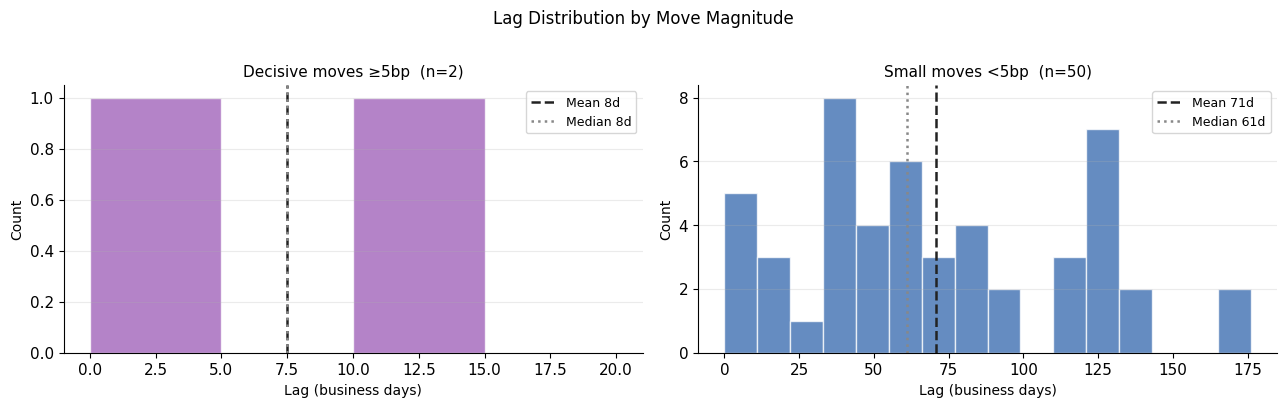

Decisive moves conditional probabilities:

───────────────────────────────────
  Decisive ≥5bp  (n=2)
───────────────────────────────────
            P(≤N) Count
N (bdays)              
1           50.0%   1/2
2           50.0%   1/2
3           50.0%   1/2
5           50.0%   1/2
7           50.0%   1/2
8           50.0%   1/2
10          50.0%   1/2
13          50.0%   1/2
14         100.0%   2/2
15         100.0%   2/2
20         100.0%   2/2
22         100.0%   2/2
30         100.0%   2/2
50         100.0%   2/2
75         100.0%   2/2
100        100.0%   2/2

Small moves conditional probabilities:

───────────────────────────────────
  Small <5bp  (n=50)
───────────────────────────────────
           P(≤N)  Count
N (bdays)              
1           2.0%   1/50
2           4.0%   2/50
3           4.0%   2/50
5           4.0%   2/50
7           4.0%   2/50
8           8.0%   4/50
10         10.0%   5/50
13         12.0%   6/50
14         12.0%   6/50
15         14.0%   7/50
20      

In [14]:
DECISIVE_BPS = 5    # threshold to classify a move as decisive

decisive = valid[valid["p75_chg_bps"].abs() >= DECISIVE_BPS]
small    = valid[valid["p75_chg_bps"].abs()  < DECISIVE_BPS]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

def regime_hist(ax, lags, label, color):
    arr = lags.dropna().values.astype(int)
    if len(arr) == 0:
        ax.set_title(f"{label} — no data")
        return
    ax.hist(arr, bins=range(0, max(arr)+10, max(5, max(arr)//15)),
            color=color, alpha=0.75, edgecolor="white", lw=0.5)
    ax.axvline(arr.mean(),            color="#222", lw=1.8, ls="--",
               label=f"Mean {arr.mean():.0f}d")
    ax.axvline(float(np.median(arr)), color="#888", lw=1.8, ls=":",
               label=f"Median {np.median(arr):.0f}d")
    ax.set_title(f"{label}  (n={len(arr)})", fontsize=11)
    ax.set_xlabel("Lag (business days)", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.25)

regime_hist(axes[0], decisive["lag_bdays"], f"Decisive moves ≥{DECISIVE_BPS}bp", "#9B59B6")
regime_hist(axes[1], small["lag_bdays"],    f"Small moves <{DECISIVE_BPS}bp",    "#3266ad")

plt.suptitle("Lag Distribution by Move Magnitude", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("regime_split.png", dpi=150, bbox_inches="tight")
plt.show()

print("Decisive moves conditional probabilities:")
cond_prob_table(decisive["lag_bdays"], f"Decisive ≥{DECISIVE_BPS}bp")
print("\nSmall moves conditional probabilities:")
cond_prob_table(small["lag_bdays"], f"Small <{DECISIVE_BPS}bp")

---
## Step 10 — Export Results
Save the full event log to CSV for Excel / further analysis.

In [15]:
export = trigger_df[[
    "date", "p75_prev", "p75_new", "p75_chg_bps", "direction",
    "effr", "lag_bdays", "effr_move_bps", "concordant", "censored"
]].copy()

export.columns = [
    "Trigger Date", "P75 Prev (%)", "P75 New (%)", "P75 Change (bps)", "Direction",
    "EFFR at Trigger (%)", "Lag (bdays)", "EFFR Move (bps)", "Concordant", "Censored"
]

export.to_csv("effr_lag_events.csv", index=False)
print("Saved: effr_lag_events.csv")
print(f"Rows: {len(export)}")
export

Saved: effr_lag_events.csv
Rows: 54


,Trigger Date,P75 Prev (%),P75 New (%),P75 Change (bps),Direction,EFFR at Trigger (%),Lag (bdays),EFFR Move (bps),Concordant,Censored
0,2025-01-13,4.34,4.33,-1.0,Down,4.33,172.0,-25.0,True,False
1,2025-01-15,4.33,4.34,1.0,Up,4.33,170.0,-25.0,False,False
2,2025-03-06,4.34,4.33,-1.0,Down,4.33,136.0,-25.0,True,False
3,2025-03-07,4.33,4.34,1.0,Up,4.33,135.0,-25.0,False,False
4,2025-03-13,4.34,4.33,-1.0,Down,4.33,131.0,-25.0,True,False
5,2025-03-14,4.33,4.34,1.0,Up,4.33,130.0,-25.0,False,False
6,2025-03-18,4.34,4.33,-1.0,Down,4.33,128.0,-25.0,True,False
7,2025-03-21,4.33,4.34,1.0,Up,4.33,125.0,-25.0,False,False
8,2025-03-24,4.34,4.33,-1.0,Down,4.33,124.0,-25.0,True,False
9,2025-03-26,4.33,4.34,1.0,Up,4.33,122.0,-25.0,False,False
